# Regularisation in Deep Learning

## Learning Objectives

1. **Diagnose** overfitting via the train/validation loss gap
2. **Derive** the L2 regularisation update: $\theta \leftarrow (1 - 2\eta\alpha)\theta - \eta\nabla_\theta L_0$
3. **Explain** why L1 produces sparse solutions while L2 produces weight shrinkage
4. **Describe** dropout: random node deletion, dropout rate $p$, weight scaling at inference
5. **Explain** early stopping: monitoring validation loss, patience, and restoring best weights
6. **Implement** L2 regularisation and dropout and demonstrate their effect on a held-out test set


## Problem Statement

### Overfitting in Deep Networks

Deep networks have millions of parameters, making them prone to memorising training data. This manifests as a large gap between training and validation loss.

### L2 Regularisation (Weight Decay)

Add a penalty on the squared weight norm:
$$L = L_0 + \alpha \|\mathbf{w}\|^2 = L_0 + \alpha \sum_i w_i^2$$

Gradient: $\partial L/\partial w_i = \partial L_0/\partial w_i + 2\alpha w_i$

SGD update with L2:
$$w_i \leftarrow w_i - \eta(\partial L_0/\partial w_i + 2\alpha w_i) = (1 - 2\eta\alpha)w_i - \eta \partial L_0/\partial w_i$$

The factor $(1-2\eta\alpha) < 1$ **shrinks** weights at each step — hence the name "weight decay".

### L1 Regularisation

$$L = L_0 + \alpha \|\mathbf{w}\|_1 = L_0 + \alpha \sum_i |w_i|$$

Gradient: $\partial L/\partial w_i = \partial L_0/\partial w_i + \alpha \text{sgn}(w_i)$

L1 pushes small weights to exactly zero (sparse solutions). L2 spreads the penalty smoothly.

### Dropout

During training, randomly set each unit to zero with probability $p$ (the **dropout rate**):
$$\tilde{h}_i = \text{Bernoulli}(1-p) \cdot h_i / (1-p)$$

The division by $(1-p)$ keeps the expected value unchanged (inverted dropout). At inference, use all units without dropout.

**Interpretation**: dropout trains an ensemble of $2^n$ thinned networks with shared weights, averaging their predictions at test time.


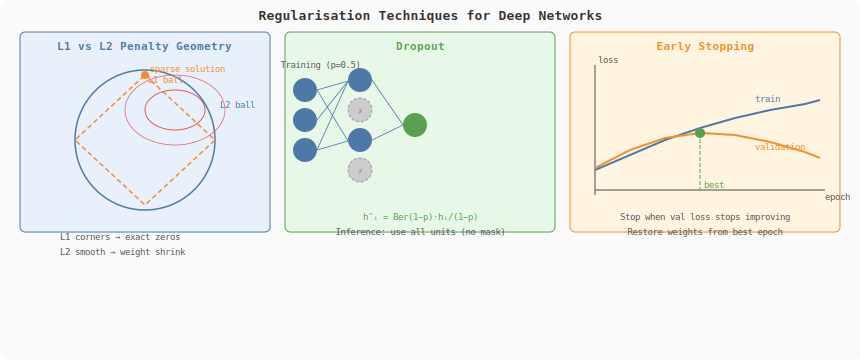

In [1]:
from IPython.display import SVG, display
svg = '''
<svg xmlns="http://www.w3.org/2000/svg" width="860" height="360" font-family="monospace" font-size="11">
  <rect width="860" height="360" fill="#fafafa" rx="8"/>
  <text x="430" y="20" text-anchor="middle" fill="#333" font-size="13" font-weight="bold">Regularisation Techniques for Deep Networks</text>

  <!-- L1 vs L2 geometry -->
  <rect x="20" y="32" width="250" height="200" rx="5" fill="#e8f0fb" stroke="#4e79a7"/>
  <text x="145" y="50" text-anchor="middle" fill="#4e79a7" font-weight="bold">L1 vs L2 Penalty Geometry</text>
  <!-- L2 circle -->
  <ellipse cx="145" cy="140" rx="70" ry="70" fill="none" stroke="#4e79a7" stroke-width="1.5"/>
  <text x="220" y="108" fill="#4e79a7" font-size="9">L2 ball</text>
  <!-- L1 diamond -->
  <polygon points="145,75 215,140 145,205 75,140" fill="none" stroke="#f28e2b" stroke-width="1.5" stroke-dasharray="5,3"/>
  <text x="148" y="83" fill="#f28e2b" font-size="9">L1 ball</text>
  <!-- contours of loss (ellipses) -->
  <ellipse cx="175" cy="110" rx="30" ry="20" fill="none" stroke="#e05c5c" stroke-width="1"/>
  <ellipse cx="175" cy="110" rx="50" ry="35" fill="none" stroke="#e05c5c" stroke-width="0.7"/>
  <!-- Intersection points -->
  <circle cx="145" cy="75" r="4" fill="#f28e2b"/>
  <text x="150" y="72" fill="#f28e2b" font-size="9">sparse solution</text>
  <text x="60" y="240" fill="#555" font-size="9">L1 corners → exact zeros</text>
  <text x="60" y="255" fill="#555" font-size="9">L2 smooth → weight shrink</text>

  <!-- Dropout -->
  <rect x="285" y="32" width="270" height="200" rx="5" fill="#e8f8e8" stroke="#59a14f"/>
  <text x="420" y="50" text-anchor="middle" fill="#59a14f" font-weight="bold">Dropout</text>
  <!-- Network without dropout -->
  <text x="320" y="68" text-anchor="middle" fill="#555" font-size="9">Training (p=0.5)</text>
  <circle cx="305" cy="90"  r="12" fill="#4e79a7"/>
  <circle cx="305" cy="120" r="12" fill="#4e79a7"/>
  <circle cx="305" cy="150" r="12" fill="#4e79a7"/>
  <!-- hidden -->
  <circle cx="360" cy="80"  r="12" fill="#4e79a7"/>
  <circle cx="360" cy="110" r="12" fill="#ccc" stroke-dasharray="3,2" stroke="#999"/>
  <text x="360" y="114" text-anchor="middle" fill="#999" font-size="9">✗</text>
  <circle cx="360" cy="140" r="12" fill="#4e79a7"/>
  <circle cx="360" cy="170" r="12" fill="#ccc" stroke-dasharray="3,2" stroke="#999"/>
  <text x="360" y="174" text-anchor="middle" fill="#999" font-size="9">✗</text>
  <!-- output -->
  <circle cx="415" cy="125" r="12" fill="#59a14f"/>
  <!-- connections (only to active units) -->
  <line x1="317" y1="90"  x2="348" y2="81"  stroke="#4e79a7" stroke-width="0.8"/>
  <line x1="317" y1="120" x2="348" y2="81"  stroke="#4e79a7" stroke-width="0.8"/>
  <line x1="317" y1="150" x2="348" y2="81"  stroke="#4e79a7" stroke-width="0.8"/>
  <line x1="317" y1="90"  x2="348" y2="141" stroke="#4e79a7" stroke-width="0.8"/>
  <line x1="317" y1="150" x2="348" y2="141" stroke="#4e79a7" stroke-width="0.8"/>
  <line x1="372" y1="80"  x2="403" y2="125" stroke="#4e79a7" stroke-width="0.8"/>
  <line x1="372" y1="140" x2="403" y2="125" stroke="#4e79a7" stroke-width="0.8"/>
  <!-- Formula -->
  <text x="420" y="220" text-anchor="middle" fill="#59a14f" font-size="9">h̃ᵢ = Ber(1−p)·hᵢ/(1−p)</text>
  <text x="420" y="235" text-anchor="middle" fill="#555" font-size="9">Inference: use all units (no mask)</text>

  <!-- Early stopping -->
  <rect x="570" y="32" width="270" height="200" rx="5" fill="#fff4e0" stroke="#f28e2b"/>
  <text x="705" y="50" text-anchor="middle" fill="#f28e2b" font-weight="bold">Early Stopping</text>
  <!-- Axes -->
  <line x1="595" y1="190" x2="825" y2="190" stroke="#666" stroke-width="1.2"/>
  <line x1="595" y1="65"  x2="595" y2="195" stroke="#666" stroke-width="1.2"/>
  <text x="825" y="200" fill="#555" font-size="9">epoch</text>
  <text x="598" y="63"  fill="#555" font-size="9">loss</text>
  <!-- Train curve (always decreasing) -->
  <polyline points="595,170 630,155 665,140 700,128 735,118 770,110 805,104 820,100" fill="none" stroke="#4e79a7" stroke-width="2"/>
  <!-- Val curve (U-shape) -->
  <polyline points="595,168 630,150 665,138 700,133 735,135 770,142 805,152 820,158" fill="none" stroke="#f28e2b" stroke-width="2"/>
  <!-- Best point marker -->
  <circle cx="700" cy="133" r="5" fill="#59a14f"/>
  <line x1="700" y1="133" x2="700" y2="190" stroke="#59a14f" stroke-width="1" stroke-dasharray="4,2"/>
  <text x="704" y="188" fill="#59a14f" font-size="9">best</text>
  <text x="755" y="102" fill="#4e79a7" font-size="9">train</text>
  <text x="755" y="150" fill="#f28e2b" font-size="9">validation</text>
  <text x="705" y="220" text-anchor="middle" fill="#555" font-size="9">Stop when val loss stops improving</text>
  <text x="705" y="235" text-anchor="middle" fill="#555" font-size="9">Restore weights from best epoch</text>
</svg>
'''
display(SVG(svg))


## Derivation

### L2 as MAP Estimation

L2 regularisation is equivalent to placing a Gaussian prior $p(w) \propto \exp(-\alpha \|w\|^2)$ on weights and performing MAP estimation:
$$\text{arg max}_{w}\, \log p(\mathcal{D}|w) + \log p(w) = \text{arg min}_{w}\, L_0(w) + \alpha \|w\|^2$$

### L1 as Laplace Prior (Sparsity)

L1 $\equiv$ Laplace prior $p(w) \propto \exp(-\alpha |w|)$. The subgradient $\alpha \text{sgn}(w_i)$ is constant in magnitude, pushing small weights to exactly 0 — unlike L2 which only scales them towards 0 asymptotically.

### Dropout Ensemble Interpretation

With $n$ units, dropout implicitly trains $2^n$ networks with shared weights. At test time, using all units with weights scaled by $(1-p)$ approximates the geometric mean of the ensemble predictions.

### Practical Guidelines

| Technique | When to use | Typical values |
|---|---|---|
| L2 weight decay | Almost always | $\alpha \in [10^{-5}, 10^{-2}]$ |
| Dropout | After large dense layers | $p \in [0.2, 0.5]$ |
| Early stopping | Always | patience = 5–20 epochs |
| Data augmentation | Vision/NLP tasks | task-specific |
| Batch normalisation | Deep networks | often replaces dropout |


In [2]:
import numpy as np


class RegNet:
    """MLP with optional L2 regularisation and dropout."""

    def __init__(self, sizes, lr=0.01, l2=0.0, dropout_p=0.0, seed=0):
        rng = np.random.default_rng(seed)
        self.lr        = lr
        self.l2        = l2
        self.dropout_p = dropout_p
        self.L         = len(sizes) - 1
        self.W  = [rng.normal(0, np.sqrt(2/sizes[i]), (sizes[i+1], sizes[i]))
                   for i in range(self.L)]
        self.b  = [np.zeros(sizes[i+1]) for i in range(self.L)]
        self.rng = rng

    @staticmethod
    def _sigmoid(z):       return 1/(1+np.exp(-z))
    @staticmethod
    def _sigmoid_p(z):     s = 1/(1+np.exp(-z)); return s*(1-s)
    @staticmethod
    def _softmax(a):
        e = np.exp(a - a.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def forward(self, X, training=True):
        """Returns (cache, Y_hat). Applies dropout if training=True."""
        cache  = []
        H      = X
        for l, (W, b) in enumerate(zip(self.W, self.b)):
            A = H @ W.T + b
            if l < self.L - 1:
                H = self._sigmoid(A)
                if training and self.dropout_p > 0:
                    mask = (self.rng.random(H.shape) > self.dropout_p) / (1 - self.dropout_p)
                    H = H * mask
                else:
                    mask = np.ones_like(H)
            else:
                H = self._softmax(A)
                mask = np.ones_like(H)
            cache.append((A, H, mask))
        return cache

    def _loss(self, Y_hat, Y_idx):
        n = len(Y_idx)
        ce = -np.log(Y_hat[np.arange(n), Y_idx] + 1e-12).mean()
        l2_pen = sum((W**2).sum() for W in self.W)
        return ce + self.l2 * l2_pen

    def backward(self, X, Y_idx, cache):
        n = X.shape[0]
        grads = [None] * self.L
        mu = cache[-1][1]
        Y_oh = np.zeros_like(mu)
        Y_oh[np.arange(n), Y_idx] = 1.0
        Delta = (mu - Y_oh) / n
        for l in range(self.L - 1, -1, -1):
            H_prev = cache[l-1][1] if l > 0 else X
            dW = Delta.T @ H_prev + 2 * self.l2 * self.W[l]
            db = Delta.sum(axis=0)
            grads[l] = (dW, db)
            if l > 0:
                A_prev, _, mask_prev = cache[l-1]
                Delta = (Delta @ self.W[l]) * self._sigmoid_p(A_prev) * mask_prev
        return grads

    def step(self, grads):
        for l, (dW, db) in enumerate(grads):
            self.W[l] -= self.lr * dW
            self.b[l]  -= self.lr * db

    def fit(self, X_tr, Y_tr, X_val, Y_val, n_epochs=300, batch=64):
        tr_losses, val_losses = [], []
        rng = np.random.default_rng(0)
        for _ in range(n_epochs):
            idx = rng.permutation(len(X_tr))
            for s in range(0, len(X_tr), batch):
                b = idx[s:s+batch]
                cache = self.forward(X_tr[b], training=True)
                grads = self.backward(X_tr[b], Y_tr[b], cache)
                self.step(grads)
            tr_hat  = self.forward(X_tr,  training=False)[-1][1]
            val_hat = self.forward(X_val, training=False)[-1][1]
            tr_losses.append(self._loss(tr_hat,  Y_tr))
            val_losses.append(self._loss(val_hat, Y_val))
        return tr_losses, val_losses

    def predict(self, X):
        return self.forward(X, training=False)[-1][1].argmax(axis=1)


# ── Generate a simple dataset (moon-shaped) ───────────────────────────────────
rng = np.random.default_rng(1)
N = 400
theta = rng.uniform(0, np.pi, N)
X0 = np.c_[np.cos(theta) + rng.normal(0,0.1,N),  np.sin(theta) + rng.normal(0,0.1,N)]
X1 = np.c_[1-np.cos(theta) + rng.normal(0,0.1,N), -np.sin(theta)+0.5 + rng.normal(0,0.1,N)]
X = np.vstack([X0, X1])
Y = np.array([0]*N + [1]*N)
idx = rng.permutation(len(X))
X, Y = X[idx], Y[idx]

n_tr = int(0.6*len(X)); n_val = int(0.2*len(X))
X_tr, Y_tr   = X[:n_tr], Y[:n_tr]
X_val, Y_val = X[n_tr:n_tr+n_val], Y[n_tr:n_tr+n_val]
X_te, Y_te   = X[n_tr+n_val:], Y[n_tr+n_val:]

n_epochs = 200
results = {}
for name, l2, dp in [('No reg', 0.0, 0.0),
                      ('L2 (α=0.01)', 0.01, 0.0),
                      ('Dropout (p=0.3)', 0.0, 0.3)]:
    net = RegNet([2, 64, 64, 2], lr=0.05, l2=l2, dropout_p=dp)
    tr_l, val_l = net.fit(X_tr, Y_tr, X_val, Y_val, n_epochs=n_epochs)
    test_acc = (net.predict(X_te) == Y_te).mean()
    results[name] = (tr_l, val_l, test_acc)
    print(f"{name:20s}: test acc={test_acc:.2%}, "
          f"final val loss={val_l[-1]:.3f}, train loss={tr_l[-1]:.3f}")


No reg              : test acc=85.00%, final val loss=0.320, train loss=0.235


L2 (α=0.01)         : test acc=80.62%, final val loss=0.703, train loss=0.666


Dropout (p=0.3)     : test acc=83.12%, final val loss=0.321, train loss=0.252


In [3]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = {'No reg': '#e05c5c', 'L2 (α=0.01)': '#4e79a7', 'Dropout (p=0.3)': '#59a14f'}

for name, (tr_l, val_l, acc) in results.items():
    color = colors[name]
    axes[0].plot(tr_l,  color=color, lw=1.5, linestyle='-',  alpha=0.8)
    axes[0].plot(val_l, color=color, lw=1.5, linestyle='--', alpha=0.8,
                 label=f"{name} (val, acc={acc:.1%})")

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training (solid) vs. Validation (dashed)', fontsize=9)
axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)

# Decision boundaries
for ax, (name, (_, _, _)) in zip(axes[1:], list(results.items())[1:]):
    net_tmp = RegNet([2, 64, 64, 2], lr=0.05,
                     l2=0.01 if 'L2' in name else 0.0,
                     dropout_p=0.3 if 'Dropout' in name else 0.0)
    net_tmp.fit(X_tr, Y_tr, X_val, Y_val, n_epochs=n_epochs)
    gx, gy = np.meshgrid(np.linspace(-1.5,2.5,150), np.linspace(-1.5,1.5,150))
    pred = net_tmp.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)
    ax.contourf(gx, gy, pred, levels=[-.5,.5,1.5], colors=['#c5e0f9','#f9c5c5'], alpha=0.4)
    ax.scatter(X_te[Y_te==0,0], X_te[Y_te==0,1], c='#4e79a7', s=12, alpha=0.6)
    ax.scatter(X_te[Y_te==1,0], X_te[Y_te==1,1], c='#e05c5c', s=12, alpha=0.6)
    acc = (net_tmp.predict(X_te) == Y_te).mean()
    ax.set_title(f'{name}\ntest acc={acc:.1%}', fontsize=9)
    ax.set_xlim(-1.5, 2.5); ax.set_ylim(-1.5, 1.5)

fig.tight_layout()
plt.savefig('regularisation.png', dpi=100, bbox_inches='tight')
plt.show()
print("Figure saved.")


Figure saved.


/tmp/ipykernel_305729/3030474596.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
